# 01 — Exploratory Data Analysis

IEEE-CIS fraud dataset (590k transactions).  
Goal: understand distributions, class imbalance, and which features separate fraud from legitimate orders.

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

con = duckdb.connect('../data/ecommerce_fraud.duckdb')
df  = con.execute('SELECT * FROM fct_fraud_signals').df()
print(df.shape)
df.head(3)

(590540, 22)


,order_id,customer_id,order_date,order_hour,order_amount,payment_method,product_category,billing_country,shipping_country,ip_country,...,country_mismatch,ip_mismatch,is_fraud,orders_on_day,high_velocity,customer_avg_order_amount,customer_ip_mismatch_count,risk_score,fraud_flag,risk_tier
0,3572472,C10486,2018-05-30,2,974.00,mastercard,Electronics,US,US,US,...,False,False,1,8,True,240.94,0.0,80,1,high
1,3572473,C8452,2018-05-30,2,210.95,visa,Electronics,US,US,US,...,False,False,0,1,False,120.41,0.0,30,0,low
2,3572474,C16132,2018-05-30,2,98.95,visa,Electronics,US,US,US,...,False,False,0,16,True,162.27,9.0,30,0,low


## 1. Class imbalance

is_fraud
Legit    569877
Fraud     20663
Name: count, dtype: int64

Fraud rate: 3.50%


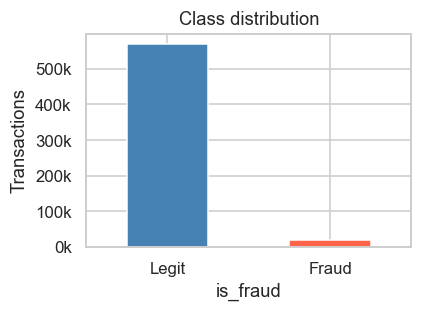

In [2]:
counts = df['is_fraud'].value_counts().rename({0: 'Legit', 1: 'Fraud'})
print(counts)
print(f"\nFraud rate: {counts['Fraud'] / counts.sum():.2%}")

fig, ax = plt.subplots(figsize=(4, 3))
counts.plot.bar(ax=ax, color=['steelblue', 'tomato'], edgecolor='white')
ax.set_title('Class distribution')
ax.set_ylabel('Transactions')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.set_xticklabels(counts.index, rotation=0)
plt.tight_layout()
plt.show()

## 2. Transaction amount distribution

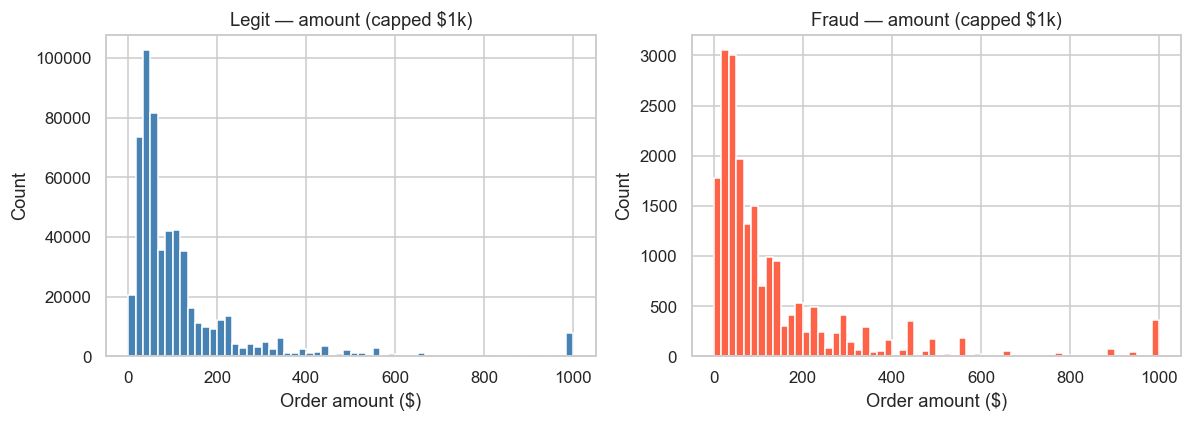

             count    mean     std   min    25%   50%    75%       max
is_fraud                                                              
0         569877.0  134.51  239.40  0.25  43.97  68.5  120.0  31937.39
1          20663.0  149.24  232.21  0.29  35.04  75.0  161.0   5191.00


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, label, color in zip(axes, [0, 1], ['steelblue', 'tomato']):
    subset = df.loc[df['is_fraud'] == label, 'order_amount']
    subset.clip(upper=1000).plot.hist(bins=60, ax=ax, color=color, edgecolor='white')
    ax.set_title(f"{'Fraud' if label else 'Legit'} — amount (capped $1k)")
    ax.set_xlabel('Order amount ($)')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

print(df.groupby('is_fraud')['order_amount'].describe().round(2))

## 3. Fraud rate by categorical features

/var/folders/1f/n6lxwpls17d60wqhwcv2nwv40000gn/T/ipykernel_92910/3301063543.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(stats[col], rotation=25, ha='right')
/var/folders/1f/n6lxwpls17d60wqhwcv2nwv40000gn/T/ipykernel_92910/3301063543.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(stats[col], rotation=25, ha='right')
/var/folders/1f/n6lxwpls17d60wqhwcv2nwv40000gn/T/ipykernel_92910/3301063543.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(stats[col], rotation=25, ha='right')


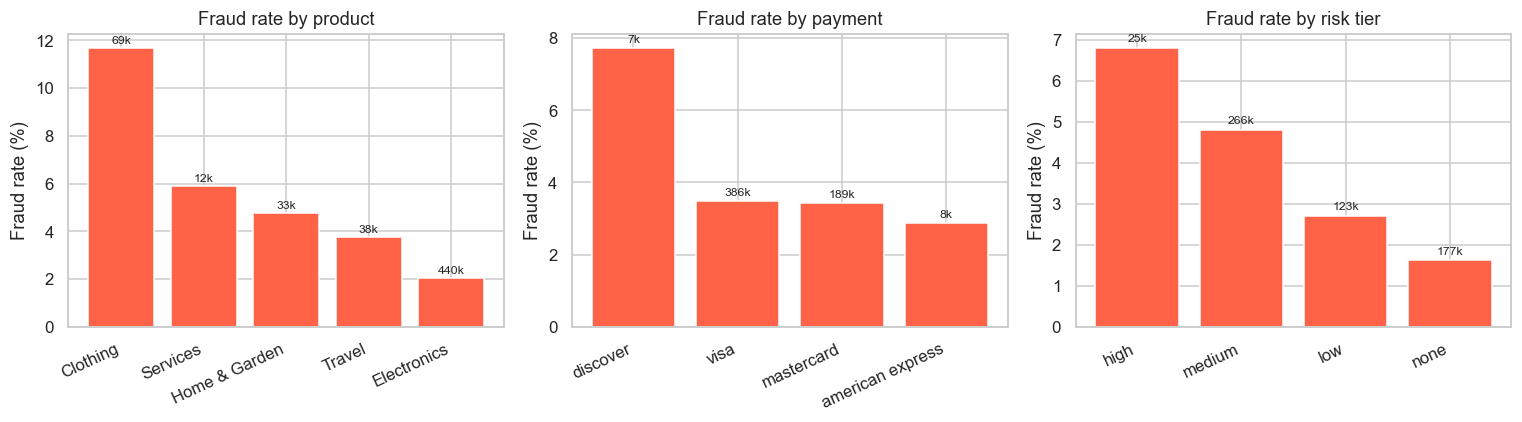

In [4]:
def fraud_rate_bar(col, ax, title):
    stats = df.groupby(col)['is_fraud'].agg(['mean', 'count']).reset_index()
    stats = stats.sort_values('mean', ascending=False)
    bars = ax.bar(stats[col], stats['mean'] * 100, color='tomato', edgecolor='white')
    ax.set_title(title)
    ax.set_ylabel('Fraud rate (%)')
    ax.set_xticklabels(stats[col], rotation=25, ha='right')
    for bar, (_, row) in zip(bars, stats.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f"{row['count']/1000:.0f}k", ha='center', va='bottom', fontsize=8)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fraud_rate_bar('product_category', axes[0], 'Fraud rate by product')
fraud_rate_bar('payment_method',   axes[1], 'Fraud rate by payment')
fraud_rate_bar('risk_tier',        axes[2], 'Fraud rate by risk tier')
plt.tight_layout()
plt.show()

## 4. Fraud rate by order hour

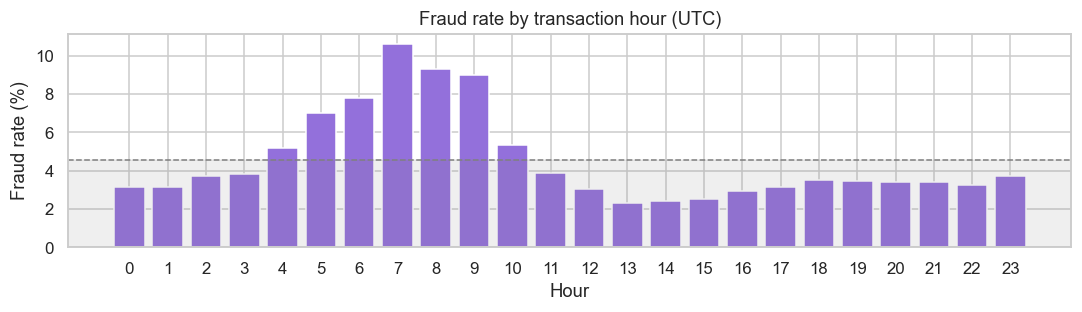

In [5]:
hourly = df.groupby('order_hour')['is_fraud'].mean() * 100

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(hourly.index, hourly.values, color='mediumpurple', edgecolor='white')
ax.axhspan(0, hourly.mean(), alpha=0.12, color='gray', label='overall mean')
ax.axhline(hourly.mean(), color='gray', linestyle='--', linewidth=1)
ax.set_title('Fraud rate by transaction hour (UTC)')
ax.set_xlabel('Hour')
ax.set_ylabel('Fraud rate (%)')
ax.set_xticks(range(24))
plt.tight_layout()
plt.show()

## 5. Account age vs fraud

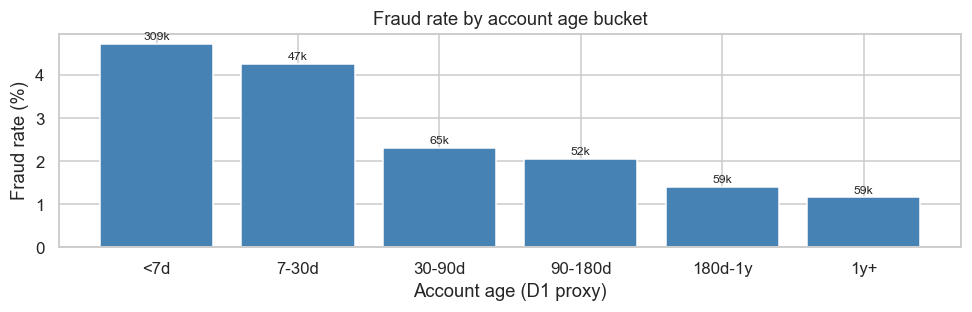

In [6]:
fig, ax = plt.subplots(figsize=(9, 3))

max_age = int(df['account_age_days'].max()) + 1
bins = [0, 7, 30, 90, 180, 365, max(730, max_age)]
labels = ['<7d', '7-30d', '30-90d', '90-180d', '180d-1y', '1y+']
df['age_bucket'] = pd.cut(df['account_age_days'], bins=bins, labels=labels, right=False)
age_stats = df.groupby('age_bucket', observed=False)['is_fraud'].agg(['mean', 'count'])

bars = ax.bar(age_stats.index, age_stats['mean'] * 100, color='steelblue', edgecolor='white')
ax.set_title('Fraud rate by account age bucket')
ax.set_ylabel('Fraud rate (%)')
ax.set_xlabel('Account age (D1 proxy)')
for bar, (_, row) in zip(bars, age_stats.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{row['count']/1000:.0f}k", ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

## 6. Rule hit rate vs actual fraud

In [7]:
rules = {
    'high_amount (>=150)':   df['order_amount'] >= 150,
    'country_mismatch':      df['country_mismatch'],
    'high_velocity':         df['high_velocity'],
    'travel_category':       df['product_category'] == 'Travel',
    'new_cust_high_amt':     df['is_new_customer'] & (df['order_amount'] >= 100),
    'late_night (1-5am)':    df['order_hour'].between(1, 5),
    'ip_mismatch':           df['ip_mismatch'],
    'new_account (<30d)':    df['account_age_days'] < 30,
}

rows = []
for name, mask in rules.items():
    hit       = mask.sum()
    precision = df.loc[mask, 'is_fraud'].mean() * 100
    recall    = (df.loc[mask, 'is_fraud'].sum() / df['is_fraud'].sum()) * 100
    rows.append({'rule': name, 'hit_rate_%': round(hit/len(df)*100, 1),
                 'precision_%': round(precision, 1), 'recall_%': round(recall, 1)})

rule_df = pd.DataFrame(rows).set_index('rule')
print(f"Baseline fraud rate: {df['is_fraud'].mean()*100:.2f}%\n")
print(rule_df.to_string())

Baseline fraud rate: 3.50%

                     hit_rate_%  precision_%  recall_%
rule                                                  
high_amount (>=150)        22.6          4.5      28.8
country_mismatch            1.2          6.6       2.3
high_velocity              70.0          3.9      78.4
travel_category             6.4          3.8       6.9
new_cust_high_amt           0.3          6.1       0.5
late_night (1-5am)         17.8          4.1      20.7
ip_mismatch                 1.2          6.5       2.3
new_account (<30d)         60.3          4.7      80.3


## 7. Risk score distribution

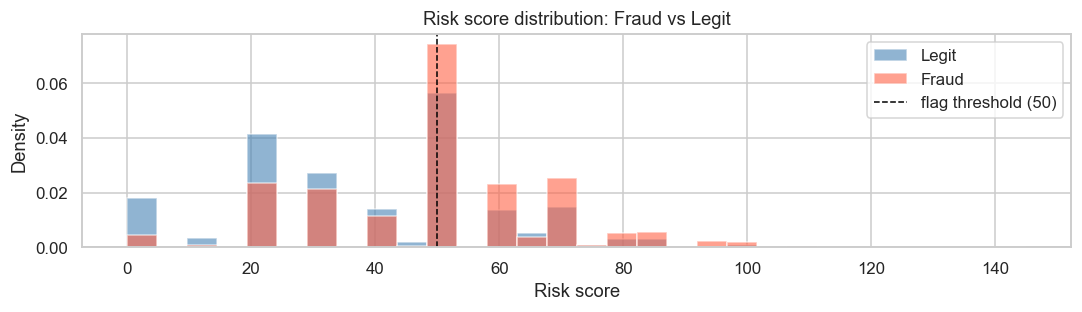

In [8]:
fig, ax = plt.subplots(figsize=(10, 3))
for label, color, zorder in [(0, 'steelblue', 1), (1, 'tomato', 2)]:
    df.loc[df['is_fraud'] == label, 'risk_score'].plot.hist(
        bins=30, ax=ax, alpha=0.6, color=color,
        label='Fraud' if label else 'Legit', density=True, zorder=zorder
    )
ax.axvline(50, color='black', linestyle='--', linewidth=1, label='flag threshold (50)')
ax.set_title('Risk score distribution: Fraud vs Legit')
ax.set_xlabel('Risk score')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Correlation heatmap (numeric features)

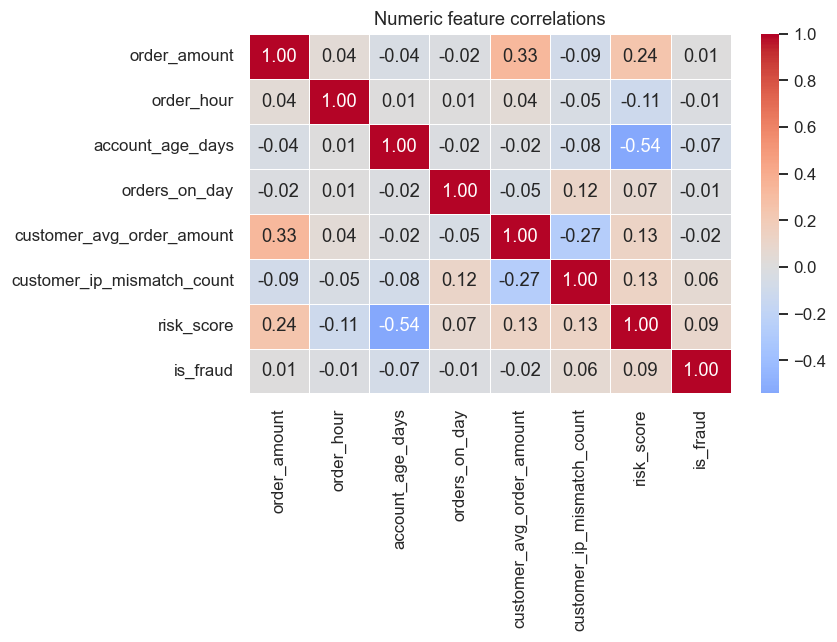

In [9]:
num_cols = ['order_amount', 'order_hour', 'account_age_days',
            'orders_on_day', 'customer_avg_order_amount',
            'customer_ip_mismatch_count', 'risk_score', 'is_fraud']

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax)
ax.set_title('Numeric feature correlations')
plt.tight_layout()
plt.show()

## Key findings

Run the notebook and fill in observations below after reviewing the charts.

- **Imbalance:** ~3.5% fraud rate — needs handling (SMOTE / class weights) in notebook 03
- **Amount:** *[check if fraud skews higher or lower]*
- **Best rule:** *[which rule has highest precision?]*
- **Worst rule:** *[which rule fires a lot but has low precision?]*
- **Hour pattern:** *[any late-night spike?]*
- **Account age:** *[does <30d really separate fraud?]*